In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as tsa
import statsmodels.tsa.arima_process as arima_process
import statsmodels.graphics.tsaplots as tsaplots

import warnings

warnings.filterwarnings("ignore")

### Create an autoregressive moving average (ARMA) process

In [3]:
process = arima_process.ArmaProcess(ar=[1,-0.8], ma=[1])

In [4]:
# the size or the number of datapoints
z = process.generate_sample(nsample=100)

In [5]:
z

array([ 0.52181236,  0.05196903,  1.26114979,  1.25473941,  1.28109741,
       -0.90183698, -1.57757712, -1.59086976,  0.25019175, -0.40111963,
       -1.12434024,  0.21568209,  1.08408265,  1.05202018, -0.0452439 ,
       -0.93739036, -0.61213336, -1.63636931, -1.36550889, -1.3526656 ,
       -0.62186593, -0.09456531,  0.42291921,  1.87867341,  1.73684301,
        0.36112388,  1.03377869, -0.04389276,  1.94226763, -0.18409363,
       -0.44163279,  0.68317446,  1.11547718,  0.12563198, -1.2283136 ,
       -1.65910987, -0.09643838, -0.34009272,  0.85366125, -0.50263156,
        0.8007942 , -0.49084886, -1.05286357, -0.46915826,  0.89559834,
        0.77165683,  1.58900087,  0.41061675, -1.34600242, -1.48890398,
        1.30213294,  1.40434743,  0.45134484, -0.35767364, -0.22216052,
       -1.38710923, -1.2360669 , -0.24141699, -0.63628722,  0.07762985,
       -0.17927524,  0.73471753,  0.61780525, -0.21144124, -1.73370382,
       -0.53535834,  0.54692048, -0.30999098, -0.43513735,  0.96

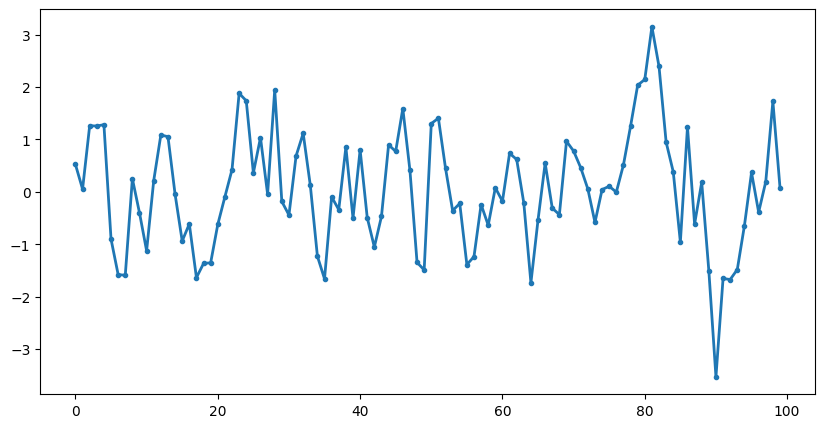

In [6]:
plt.figure(figsize=(10,5)) 
plt.plot(z, linewidth=2,marker='.')

### Autocorrelations

In [7]:
# the number of lags or the number of coefficients (20)
acf = process.acf(lags=20)

In [8]:
acf

array([1.        , 0.8       , 0.64      , 0.512     , 0.4096    ,
       0.32768   , 0.262144  , 0.2097152 , 0.16777216, 0.13421773,
       0.10737418, 0.08589935, 0.06871948, 0.05497558, 0.04398047,
       0.03518437, 0.0281475 , 0.022518  , 0.0180144 , 0.01441152])

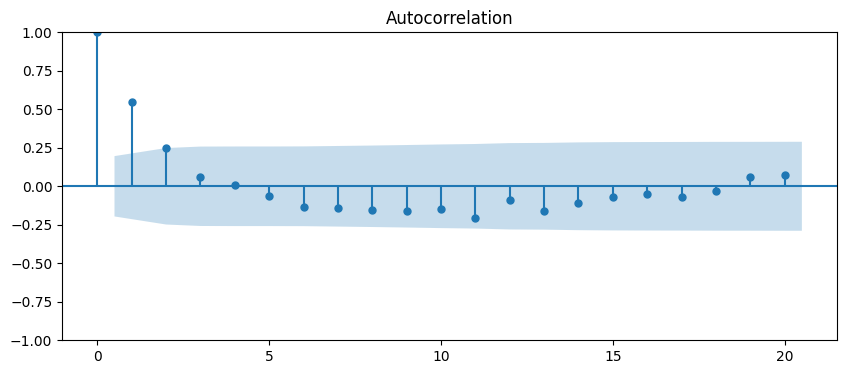

In [9]:
fig, ax = plt.subplots(figsize=(10,4)) 
tsaplots.plot_acf(z, lags=20, ax=ax) 
plt.show()

In [23]:
sunspots = pd.read_csv('data/Sunspots.csv') 
sunspots.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7


In [24]:

# convert dates into a timestamp object
pd.to_datetime(sunspots.loc[0, 'Date'])

Timestamp('1749-01-31 00:00:00')

In [25]:
sunspots = sunspots.set_index(pd.to_datetime(sunspots['Date']))

In [26]:
sunspots.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
Date,,,
1749-01-31,0,1749-01-31,96.7
1749-02-28,1,1749-02-28,104.3
1749-03-31,2,1749-03-31,116.7
1749-04-30,3,1749-04-30,92.8
1749-05-31,4,1749-05-31,141.7


In [27]:
# drop the first column, we need only two columns for creating a Time Series
sunspots.drop(columns=['Unnamed: 0', 'Date'], inplace=True)

In [28]:
sunspots.columns

Index(['Monthly Mean Total Sunspot Number'], dtype='object')

In [29]:
sunspots

,Monthly Mean Total Sunspot Number
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7
...,...
2020-09-30,0.6
2020-10-31,14.4
2020-11-30,34.0


In [16]:
sunspots.rename(columns={'Monthly Mean Total Sunspot Number':'values'}, inplace=True)

In [17]:
sunspots

,values
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7
...,...
2020-09-30,0.6
2020-10-31,14.4
2020-11-30,34.0


<Axes: xlabel='Date'>

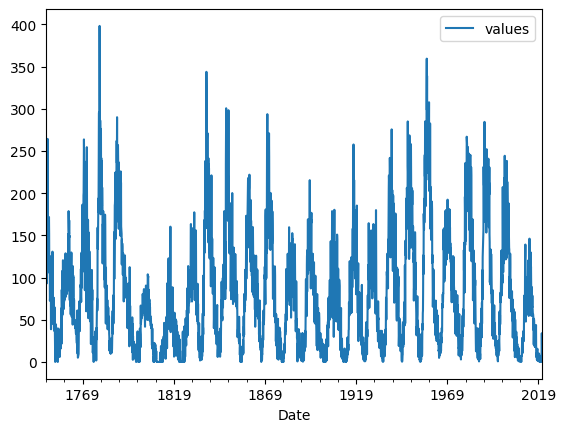

In [18]:
sunspots.plot()

### Although the sunspots data is not stationary, the difference of sunspots from one month to the next is believed to be stationary
### For the data to be stationary, the autocorrelations should decay to zero.
Stationary processes are more difficult to predict than non-stationary processes since they lack a trend, seasonality, or cycles.
However, stationary processes may still contain structure in the form of the autocorrelation function, which can be estimated and used to make short-term predictions.

- None stationary data

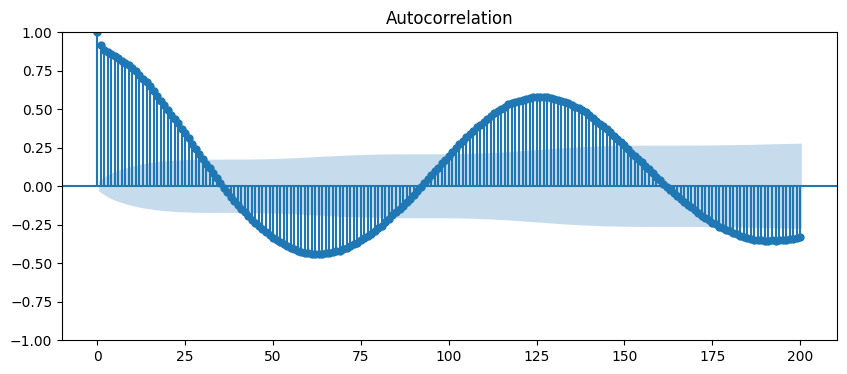

In [19]:
fig, ax = plt.subplots(figsize=(10,4)) 
tsa.plot_acf(sunspots, lags=200, ax=ax) 
plt.show()

- Stationary data

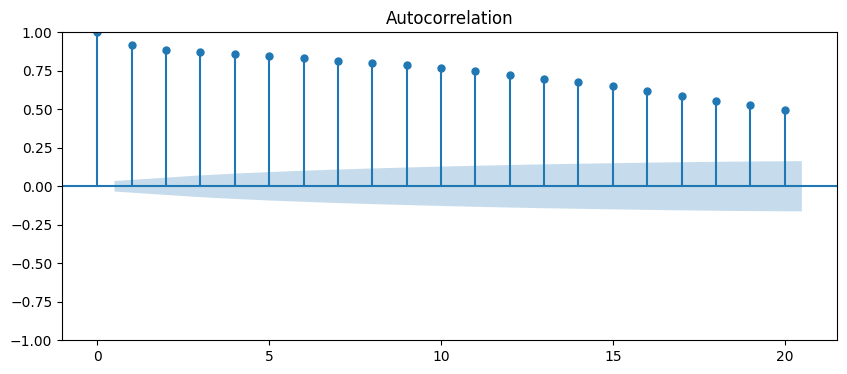

In [20]:
fig, ax = plt.subplots(figsize=(10,4))
tsaplots.plot_acf(sunspots, lags=20, ax=ax)
plt.show()

### Take a difference
The sun dataset is not stationary, 
but the data between the months it is stationary

In [21]:
diff_sunspots=sunspots.diff().dropna()

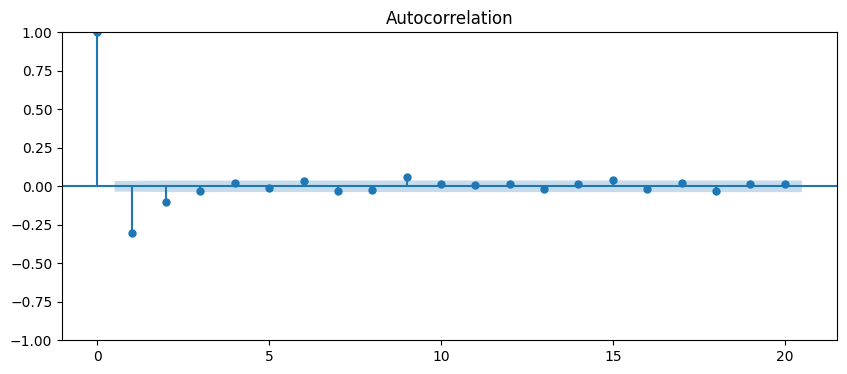

In [22]:
# Wow, this is not decaying at all, it behaves sort of sinusoidally and even after 200 lags is not seeming to decay.
# So this is a very good indication that the sunspots data is not stationary, which is something that we already knew.
fig, ax = plt.subplots(figsize=(10,4))
tsaplots.plot_acf(diff_sunspots, lags=20, ax=ax)
plt.show()

# y=t+c+s+r
▪ Trend (t): Long-term behavior
▪ Cycles (c): Variations that break with the trend, but do not happen with a set period i.e. random low-frequency variations
▪ Seasonality (s): Known periodic behavior
▪ Residue (r): Any other behavior